# Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Funciones

In [9]:
def explorar_senal_completa(filepath, sample_rate):
    """
    Carga el archivo IQ completo en memoria RAM y visualiza 
    su contenido de manera eficiente mediante diezmado gráfico,
    preservando los datos originales para el modelo de IA.
    """
    print(f"Iniciando carga de {filepath} en RAM...")
    start_time = time.time()
    
    # 1. CARGA TOTAL EN RAM: Lectura binaria pura de los datos I/Q
    # El tipo np.complex64 (Complex Float de 32 bits) es el extraído de tu XML
    senal_iq = np.fromfile(filepath, dtype=np.complex64)
    
    tiempo_carga = time.time() - start_time
    num_samples = len(senal_iq)
    duracion_total = num_samples / sample_rate
    
    print(f"Carga completada en {tiempo_carga:.3f} segundos.")
    print(f"Muestras totales cargadas: {num_samples} ({duracion_total} s. a {sample_rate/1e6} MSps).")
    
    # 2. PROCESAMIENTO MATEMÁTICO: Calculamos la envolvente (magnitud)
    # Tu CPU procesará esta operación vectorizada en milisegundos
    magnitud_total = np.abs(senal_iq)
    
    # 3. VISUALIZACIÓN INTELIGENTE (Downsampling solo para renderizado)
    # Tomamos 1 de cada 1000 muestras para no colapsar la CPU al dibujar los píxeles
    factor_diezmado = 1000
    senal_diezmada = magnitud_total[::factor_diezmado]
    tiempo_diezmado = np.arange(0, num_samples, factor_diezmado) / sample_rate
    
    plt.figure(figsize=(14, 8))
    
    # --- GRÁFICA 1: Vista Macro (1 Segundo Completo) ---
    plt.subplot(2, 1, 1)
    plt.plot(tiempo_diezmado, senal_diezmada, color='darkblue', linewidth=0.6)
    plt.title('Vista Macro (1 Segundo Completo) - Envolvente Diezmada (1/1000) - Controlador YUNZHUO H16')
    plt.xlabel('Tiempo (segundos)')
    plt.ylabel('Amplitud |IQ|')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # --- GRÁFICA 2: Vista Micro (Primeros 2 milisegundos, Máxima Resolución) ---
    # Extraemos 200,000 muestras para ver la señal en su estado puro, sin alterar
    muestras_micro = int(sample_rate * 0.000005) 
    tiempo_micro = np.arange(muestras_micro) / sample_rate
    
    plt.subplot(2, 1, 2)
    plt.plot(tiempo_micro * 1000, np.real(senal_iq[:muestras_micro]), label='I (Fase)', alpha=0.8)
    plt.plot(tiempo_micro * 1000, np.imag(senal_iq[:muestras_micro]), label='Q (Cuadratura)', alpha=0.8)
    plt.title('Vista Micro (Primeros 2 ms) - Componentes I/Q Originales a 100 MSps')
    plt.xlabel('Tiempo (milisegundos)')
    plt.ylabel('Amplitud Lineal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return senal_iq

# Código

Iniciando carga de ../download_data/YUNZHUO%20H16/YUNZHUO H16/pack1_0-1s.iq en RAM...
Carga completada en 0.214 segundos.
Muestras totales cargadas: 100000000 (1.0 s. a 100.0 MSps).


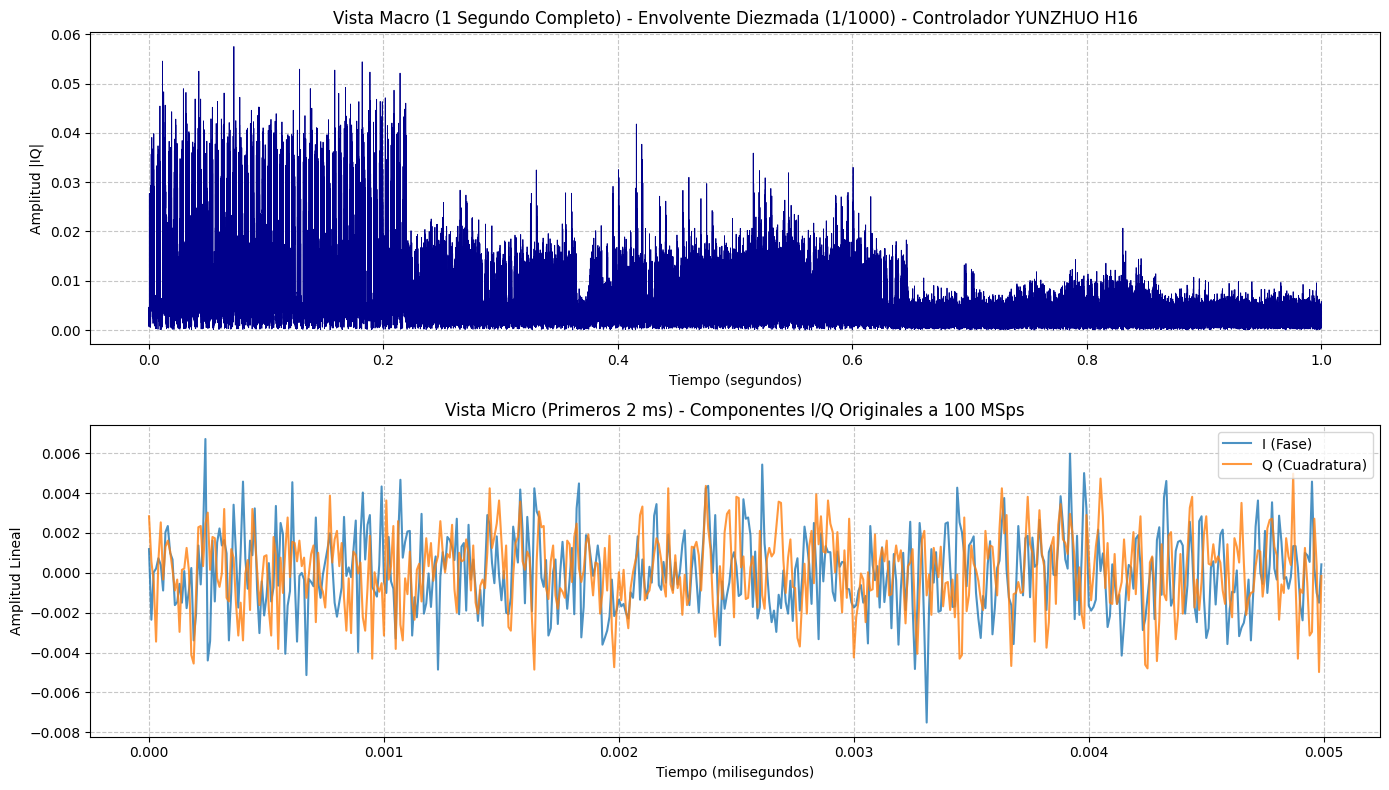

In [10]:
# --- EJECUCIÓN PRINCIPAL ---
# Parámetros extraídos de los metadatos (XML) del USRP X310
archivo_iq = '../download_data/YUNZHUO%20H16/YUNZHUO H16/pack1_0-1s.iq' 
frecuencia_muestreo = 100e6  # 100 Mega Muestras por segundo

# Llamada a la función principal
senal_completa = explorar_senal_completa(archivo_iq, frecuencia_muestreo)

Filtrado del ruido de fondo

In [21]:
power = np.abs(senal_completa)**2
bg_noise = np.median(power)
sens_factor = 5
treshold = sens_factor * bg_noise

In [22]:
active_index = np.where(power > treshold)[0]

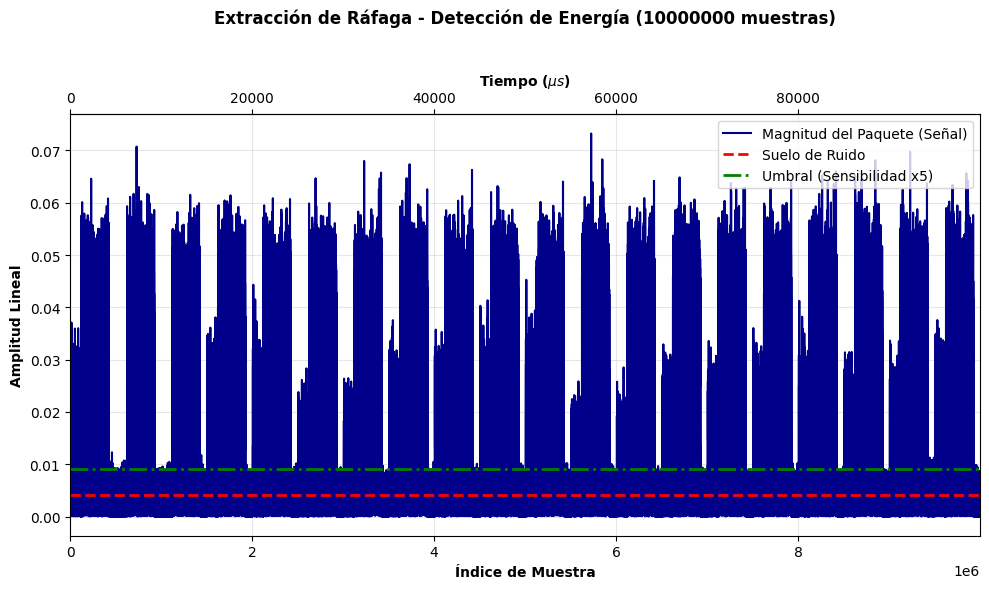

In [30]:
if len(active_index) > 0:
    start_pckt = active_index[0]
    samples_to_extract = 10000000
    
    # Extraemos el paquete (asegurándonos de no salirnos del array)
    end_pckt = min(start_pckt + samples_to_extract, len(senal_completa))
    pure_pckt = senal_completa[start_pckt : end_pckt]

    # --- ZONA DE VISUALIZACIÓN CON DOBLE EJE X ---
    # Usamos subplots para tener acceso directo al objeto de los ejes (ax)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Dibujamos la magnitud de la señal recortada en el eje principal (muestras)
    ax.plot(np.abs(pure_pckt), label='Magnitud del Paquete (Señal)', color='darkblue')
    
    # 2. Convertimos el Ruido y el Umbral de Potencia a Magnitud para poder dibujarlos
    ruido_magnitud = np.sqrt(bg_noise)
    umbral_magnitud = np.sqrt(treshold)
    
    # 3. Añadimos las líneas horizontales
    ax.axhline(y=ruido_magnitud, color='red', linestyle='--', linewidth=2, label='Suelo de Ruido')
    ax.axhline(y=umbral_magnitud, color='green', linestyle='-.', linewidth=2, label=f'Umbral (Sensibilidad x{sens_factor})')
    
    # 4. CONFIGURACIÓN DEL EJE SECUNDARIO (TIEMPO)
    fs = 100e6  # 100 MSps de tu archivo XML
    
    # Definimos las funciones matemáticas para convertir entre ambas escalas
    def muestras_a_tiempo(x):
        return (x / fs) * 1e6  # Convertimos a microsegundos (us)
        
    def tiempo_a_muestras(x):
        return (x * fs) / 1e6
        
    # Añadimos el eje en la parte superior ("top")
    secax = ax.secondary_xaxis('top', functions=(muestras_a_tiempo, tiempo_a_muestras))
    secax.set_xlabel(r'Tiempo ($\mu s$)', fontweight='bold')
    
    # 5. Formato académico de la gráfica
    # Añadimos un 'pad' al título para que no se superponga con el nuevo eje superior
    ax.set_title(f"Extracción de Ráfaga - Detección de Energía ({len(pure_pckt)} muestras)\n", pad=20, fontweight='bold')
    ax.set_xlabel("Índice de Muestra", fontweight='bold')
    ax.set_ylabel("Amplitud Lineal", fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Ajustamos los límites de la gráfica para que no haya espacios en blanco a los lados
    ax.set_xlim([0, len(pure_pckt) - 1])
    
    fig.tight_layout()
    plt.show() # <-- Paréntesis añadidos y listos
else:
    print("No se ha detectado ninguna señal por encima del umbral.")

Calculando el espectrograma mediante STFT...


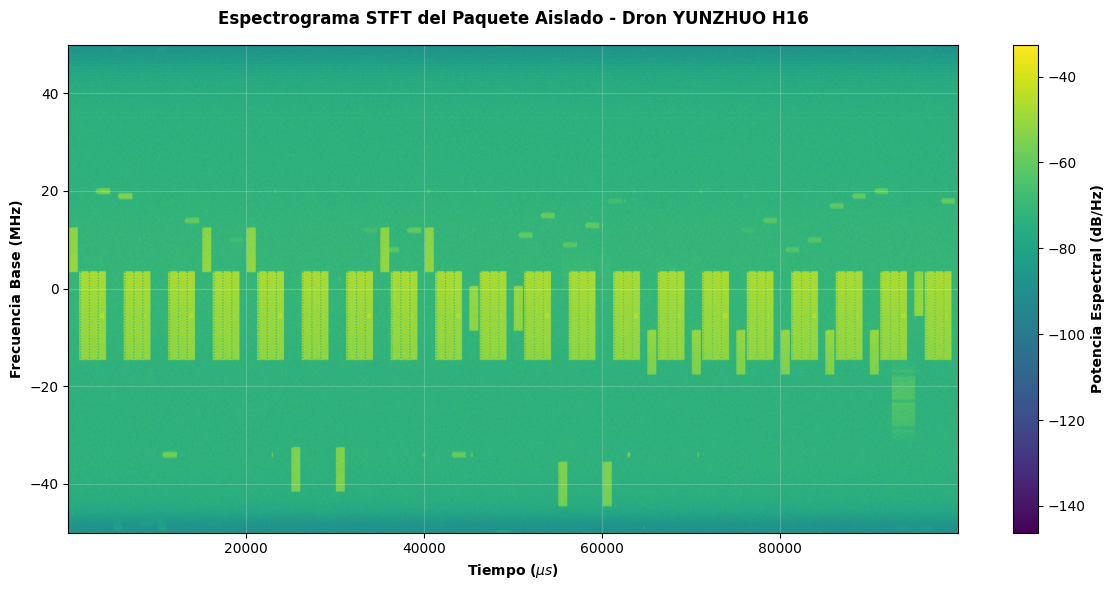

In [31]:
# --- ZONA DE ANÁLISIS TIEMPO-FRECUENCIA (ESPECTROGRAMA) ---
# Asegúrate de importar esto al principio de tu script si no lo tienes:
# import matplotlib.pyplot as plt

print("Calculando el espectrograma mediante STFT...")

plt.figure(figsize=(12, 6))

# Parámetros de la STFT
nfft_size = 1024       # Resolución en frecuencia (tamaño de la ventana FFT)
overlap = 512          # Solapamiento para suavidad temporal
fs_mhz = fs / 1e6      # Pasamos la Fs a MHz para que el eje Y sea legible (100 MHz)

# La función specgram de matplotlib maneja señales complejas automáticamente
# y grafica las frecuencias negativas y positivas (-Fs/2 a Fs/2)
Pxx, freqs, bins, im = plt.specgram(
    pure_pckt, 
    NFFT=nfft_size, 
    Fs=fs_mhz, 
    noverlap=overlap, 
    cmap='viridis',    # 'viridis' o 'jet' son los estándares en revistas científicas
    scale='dB'         # Escala logarítmica para ver el ruido de fondo y la señal
)

# Formato académico riguroso
plt.title(f'Espectrograma STFT del Paquete Aislado - Dron YUNZHUO H16', fontweight='bold', pad=15)
plt.xlabel(r'Tiempo ($\mu s$)', fontweight='bold')
plt.ylabel('Frecuencia Base (MHz)', fontweight='bold')

# Añadimos la barra de color para la potencia
cbar = plt.colorbar(im)
cbar.set_label('Potencia Espectral (dB/Hz)', fontweight='bold')

plt.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.show()